<div style="margin-bottom: 32px;">
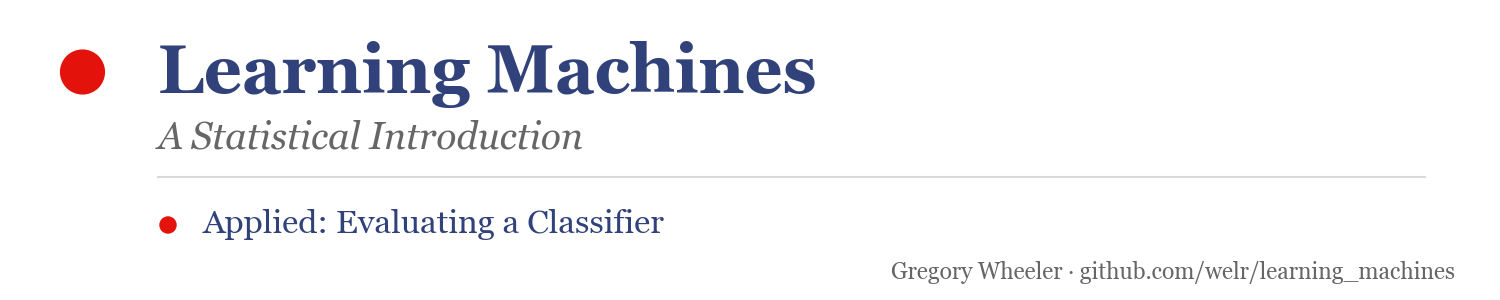
</div>


# Applied — Evaluating a Classifier

A short companion to the model-evaluation chapter. We train a classifier and then put it through the chapter's evaluation kit: a confusion matrix, precision / recall / F$_1$, and an ROC curve with its AUC.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Colab: fetch the plot-style helper if it isn't beside this notebook
import os as _os, urllib.request as _ur
if not _os.path.exists("mlone_theme.py"):
    _BASE = "https://raw.githubusercontent.com/welr/learning_machines/main/"
    for _f in ("mlone_theme.py", "mlone_style.mplstyle"):
        _ur.urlretrieve(_BASE + _f, _f)
import mlone_theme as mt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, roc_curve, roc_auc_score)

plt.style.use("mlone_style.mplstyle"); mt.set_notebook_mode()

## A classifier to evaluate

The Wisconsin breast-cancer data: 569 tumors, thirty measurements each, labeled malignant or benign. We fit a logistic-regression classifier; everything after is about *judging* it. A classifier outputs probabilities, so its behavior depends on the threshold we choose—and evaluation has to grapple with that.

In [2]:
data = load_breast_cancer()
X_tr, X_te, y_tr, y_te = train_test_split(data.data, data.target, test_size=0.25,
                                          random_state=0, stratify=data.target)
scaler = StandardScaler().fit(X_tr)
clf = LogisticRegression(max_iter=5000).fit(scaler.transform(X_tr), y_tr)
proba = clf.predict_proba(scaler.transform(X_te))[:, 1]      # P(benign)
pred = (proba >= 0.5).astype(int)

## The confusion matrix, and the metrics built on it

At a threshold of 0.5 the confusion matrix counts true and false positives and negatives; precision, recall, and F$_1$ are ratios of those four counts (Chapter 6).

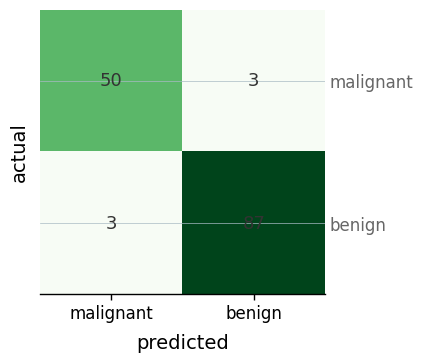

precision 0.967 | recall 0.967 | F1 0.967


In [3]:
cm = confusion_matrix(y_te, pred)
fig, ax = plt.subplots(figsize=(3.9, 3.7))
ax.imshow(cm, cmap="Greens")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=13)
ax.set_xticks([0, 1]); ax.set_xticklabels(["malignant", "benign"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["malignant", "benign"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
plt.show()
print(f"precision {precision_score(y_te, pred):.3f} | "
      f"recall {recall_score(y_te, pred):.3f} | F1 {f1_score(y_te, pred):.3f}")

## ROC and AUC: every threshold at once

Sweeping the threshold from 1 down to 0 traces the ROC curve—true-positive rate against false-positive rate. The area under it (AUC) is the probability the model ranks a random positive above a random negative (Chapter 6): a single, threshold-free summary of how well it separates the classes.

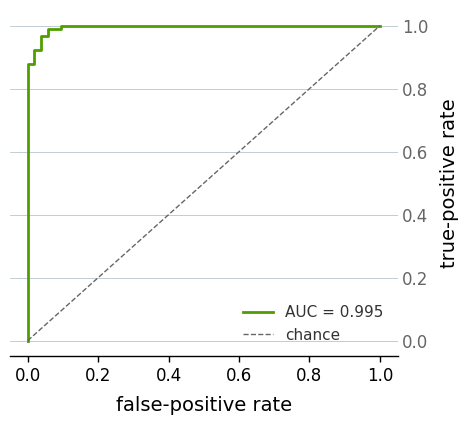

In [4]:
fpr, tpr, _ = roc_curve(y_te, proba)
auc = roc_auc_score(y_te, proba)
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot(fpr, tpr, color=mt.GREEN, lw=2, label=f"AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], color=mt.GRAY, ls="--", lw=1, label="chance")
ax.set_xlabel("false-positive rate"); ax.set_ylabel("true-positive rate")
ax.legend(); mt.apply_book_style(ax)
plt.show()

## Try next

- Move the threshold off 0.5 and watch precision trade against recall. For a cancer screen, which error is worse—and which way should the threshold move?
- A model can post a high AUC yet be poorly *calibrated* (Chapter 6). Bin the predicted probabilities and plot predicted against observed frequency: does "0.7" really mean 70%?